## Step 2: Nelson Siegel curve fitting


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [6]:
def nelson_siegel(t, beta0, beta1, beta2, lamb):
    return beta0 + (beta1 + beta2) * (1 - np.exp(-t / lamb)) / (t / lamb) - beta2 * np.exp(-t / lamb)

In [7]:
def error(params, t, y):
    return np.sum((nelson_siegel(t, *params) - y) ** 2)

In [ ]:
df = pd.read_csv('raw_yield_curve_data.csv')
t = df['maturity_years'].values
y = df['yield'].values

print("Raw Yield Curve Data:")
print(df)
print(f"\nMaturities: {t}")
print(f"Yields: {y}")

Raw Yield Curve Data:
    maturity_years  yield
0         0.083333   3.72
1         0.250000   3.67
2         0.500000   3.58
3         1.000000   3.44
4         2.000000   3.47
5         3.000000   3.55
6         5.000000   3.74
7         7.000000   3.97
8        10.000000   4.21
9        20.000000   4.79
10       30.000000   4.85

Maturities: [ 0.08333333  0.25        0.5         1.          2.          3.
  5.          7.         10.         20.         30.        ]
Yields: [3.72 3.67 3.58 3.44 3.47 3.55 3.74 3.97 4.21 4.79 4.85]


In [ ]:
beta0_guess = y[-1]                
beta1_guess = y[0] - y[-1]        
beta2_guess = 0                  
lamb_guess = 0                     

initial_guess = [beta0_guess, beta1_guess, beta2_guess, lamb_guess]

bounds = [
    (0, 10),       
    (-10, 10),      
    (-10, 10),        
    (0.1, 10)       
]

In [10]:
result = minimize(
    error,
    initial_guess,
    args=(t, y),
    bounds=bounds,
    method="L-BFGS-B"
)
print(result.success)
print(result.message)
print("\nFitted Parameters:")
print(f"beta0: {result.x[0]:.4f}")
print(f"beta1: {result.x[1]:.4f}")
print(f"beta2: {result.x[2]:.4f}")
print(f"lambda: {result.x[3]:.4f}")

True
CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Fitted Parameters:
beta0: 5.2212
beta1: -1.4862
beta2: -3.1042
lambda: 2.1841


In [11]:
beta0, beta1, beta2, lamb = result.x

print("beta0:", beta0)
print("beta1:", beta1)
print("beta2:", beta2)
print("lamb:", lamb)


beta0: 5.221197900793064
beta1: -1.4862096799340685
beta2: -3.104197670545205
lamb: 2.184065328376539


In [12]:
def yield_curve(maturity):
    return nelson_siegel(maturity, beta0, beta1, beta2, lamb)


In [13]:
print(yield_curve(4.5))
print(yield_curve(6.2))


3.67259943303771
3.8803309081936503


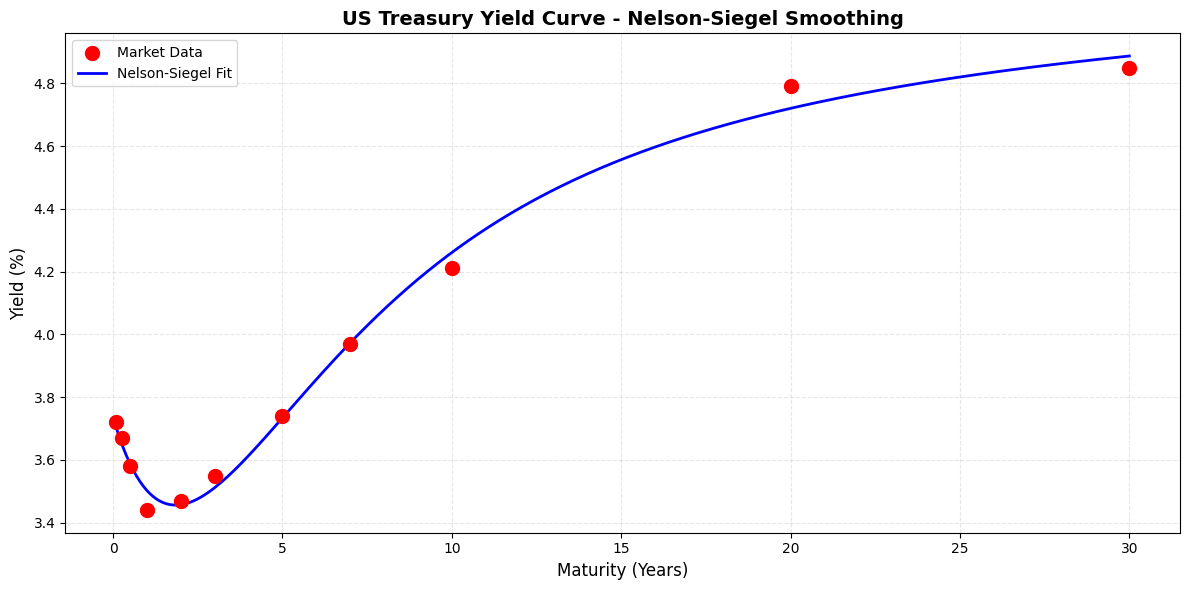

In [14]:
t_grid = np.linspace(min(t), max(t), 300)
fitted_yields = yield_curve(t_grid)

plt.figure(figsize=(12, 6))
plt.scatter(t, y, color="red", s=100, label="Market Data", zorder=3)
plt.plot(t_grid, fitted_yields, 'b-', linewidth=2, label="Nelson-Siegel Fit")
plt.xlabel("Maturity (Years)", fontsize=12)
plt.ylabel("Yield (%)", fontsize=12)
plt.title("US Treasury Yield Curve - Nelson-Siegel Smoothing", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 3: Bond pricing engine 

In [27]:
def present_value(face_value, coupon_rate, yield_rate, time):

    N = time*2
    PMT = face_value * coupon_rate / 2
    r = yield_rate / 2

    pv_coupons = PMT * (1 - (1 + r) ** -N) / r
    pv_face = face_value / (1 + r) ** N
    return pv_coupons + pv_face

In [42]:
tenors = [1/12, 0.25,0.5, 1, 2, 3, 5, 7, 10, 20, 30]

print("Bond Pricing:")
print("-" * 70)
results = []
for t in tenors:
    market_yield = yield_curve(t)
    coupon = market_yield
    price = present_value(1000, coupon, market_yield, t)
    print(f"Maturity: {t:5.2f}Y | Market Yield: {market_yield:5.2f}% | Price: ${price:7.2f}")
    results.append({'maturity': t, 'market_yield': market_yield, 'price': price})

df_results = pd.DataFrame(results)

Bond Pricing:
----------------------------------------------------------------------
Maturity:  0.08Y | Market Yield:  3.71% | Price: $1000.00
Maturity:  0.25Y | Market Yield:  3.65% | Price: $1000.00
Maturity:  0.50Y | Market Yield:  3.59% | Price: $1000.00
Maturity:  1.00Y | Market Yield:  3.50% | Price: $1000.00
Maturity:  2.00Y | Market Yield:  3.46% | Price: $1000.00
Maturity:  3.00Y | Market Yield:  3.51% | Price: $1000.00
Maturity:  5.00Y | Market Yield:  3.73% | Price: $1000.00
Maturity:  7.00Y | Market Yield:  3.97% | Price: $1000.00
Maturity: 10.00Y | Market Yield:  4.26% | Price: $1000.00
Maturity: 20.00Y | Market Yield:  4.72% | Price: $1000.00
Maturity: 30.00Y | Market Yield:  4.89% | Price: $1000.00
